# 데이터 준비

In [7]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


### 스타벅스 공식 컬러 팔레트 정의

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

SB_DEEP_GREEN = '#1E3932'
SB_GREEN      = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD       = '#CBA258'
SB_GREY       = '#A2AAAD'
SB_BLACK      = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})


sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

In [8]:
merge_df = pd.read_csv("../../Data/merged_df.csv")

In [9]:
merge_df.head(1)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label
0,78afa995795e4d85b5d9ceeca43f5fef,received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,1,F,75.0,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0,0,0,5.0,5.0,7.0,1.0,1.0,1.0,0.0,bogo_3


In [10]:
merge_df['offer_label'].value_counts()

offer_label
discount_3         20189
discount_2         20095
bogo_4             19097
bogo_2             18192
bogo_1             18009
bogo_3             16151
discount_4         15714
informational_2    14305
discount_1         13671
informational_1    11761
Name: count, dtype: int64

In [11]:
merge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

#### noinfo_merge_df : informational이 없는 merge_df

In [12]:
exclude_labels = ['informational_1', 'informational_2']

noinfo_merge_df = merge_df[~merge_df['offer_label'].isin(exclude_labels)]

print("남아있는 오퍼:", noinfo_merge_df['offer_label'].unique())

남아있는 오퍼: <StringArray>
[    'bogo_3', 'discount_1', 'discount_4', 'discount_3',     'bogo_2',
     'bogo_4', 'discount_2',     'bogo_1',          nan]
Length: 9, dtype: str


In [13]:
ex_shape = merge_df.shape
print(ex_shape)

noinfo_shape = noinfo_merge_df.shape
print(noinfo_shape)

(306137, 22)
(280071, 22)


##### 오퍼 기준으로 하는거면 포함해서 계산, 거래 기준으로 계산하면 제외

# 대시보드 1 : 전체 (핵심지표 소개)

1. 총 오퍼 퍼널 분석

1-1. 총 발송 수, 총 열람 수, 총 완료 수

1-2. 오퍼 단계별 전환율(전체 기준 or 필터 걸어서 각각도)



2. 총 매출

3. 총 거래 건수

4. 객단가 - 제일 큰 단위(범주)

5. 채널별 고객 수

6. 전체 고객 수

In [14]:
merge_df['event'].value_counts()

event
transaction    138953
received        76277
viewed          57725
completed       33182
Name: count, dtype: int64

## 1-1. 총 오퍼 퍼널 분석 (총 발송 수, 총 열람 수, 총 완료 수)

오퍼기준 -> 포함

Received 건수: 76,277
Viewed 건수: 57,725
Completed 건수: 33,182


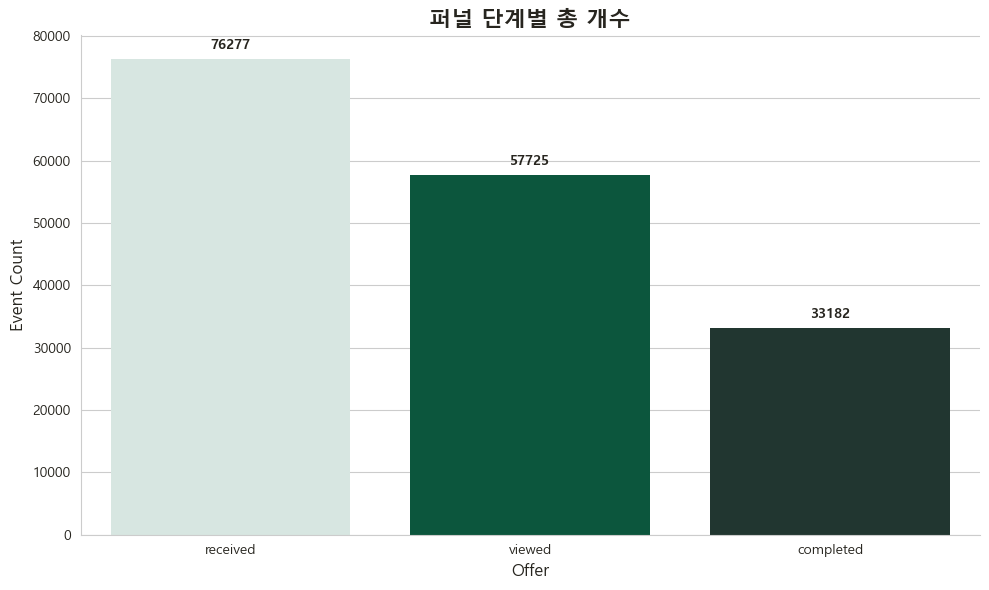

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

offer_events = ['received', 'viewed', 'completed']
event_counts = merge_df['event'].value_counts().reindex(offer_events)

print(f"Received 건수: {event_counts['received']:,}")
print(f"Viewed 건수: {event_counts['viewed']:,}")
print(f"Completed 건수: {event_counts['completed']:,}")

plot_df = event_counts.reset_index()
plot_df.columns = ['Stage', 'Count']

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=plot_df, x='Stage', y='Count', 
                 palette=[SB_LIGHT_GREEN, SB_GREEN, SB_DEEP_GREEN], 
                 hue='Stage', legend=False)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold')

plt.title('퍼널 단계별 총 개수', fontsize=16, fontweight='bold')
plt.ylabel('Event Count', fontsize=12)
plt.xlabel('Offer', fontsize=12)

plt.tight_layout()
plt.show()

## 1-2. 총 오퍼 퍼널 분석 (오퍼 단계별 전환율)

앞에 맞춰서 뒤의 비율

태블로에서는 각각

거래 기준 -> 제외

In [16]:
event_counts = noinfo_merge_df['event'].value_counts().reindex(offer_events)


오퍼 반응률 (Received -> Viewed): 75.68%
오퍼 반응률 (Viewed -> Completed): 57.48%


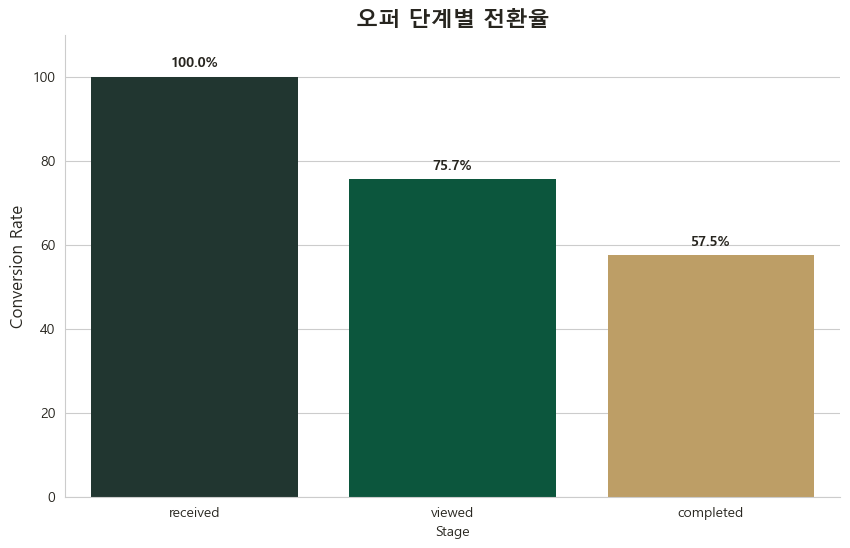

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

#오퍼 열람률과 오퍼 반응률 구하기
rv_rate = (event_counts['viewed'] / event_counts['received']) * 100
vc_rate = (event_counts['completed'] / event_counts['viewed']) * 100

print(f"오퍼 반응률 (Received -> Viewed): {rv_rate:.2f}%")
print(f"오퍼 반응률 (Viewed -> Completed): {vc_rate:.2f}%")


rates = [100, rv_rate, vc_rate] 
rate_df = pd.DataFrame({'Stage': offer_events, 'Rate': rates})

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=rate_df, x='Stage', y='Rate', 
                 palette=[SB_DEEP_GREEN, SB_GREEN, SB_GOLD], 
                 hue='Stage', legend=False)
                 
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold')

plt.title('오퍼 단계별 전환율', fontsize=16, fontweight='bold')
plt.ylabel('Conversion Rate', fontsize=12)
plt.ylim(0, 110) 
plt.show()

## 2. 총 매출

##### 해석

오른쪽에 있을수록 고객들이 좋아하고 잘 참여하는 오퍼 (높은 완료율)

위에 있을수록 한 번 발송할 때마다 돈을 많이 벌어다 주는 오퍼 (높은 수익성)

점이 클수록 회사 전체 매출에 기여하는 바가 큰 오퍼 (큰 규모)

색깔은 이게 BOGO인지 Discount인지 구분 (오퍼 유형)

##### 해석

오른쪽에 있을수록 고객들이 좋아하고 잘 참여하는 오퍼 (높은 완료율)

위에 있을수록 한 번 발송할 때마다 돈을 많이 벌어다 주는 오퍼 (높은 수익성)

점이 클수록 회사 전체 매출에 기여하는 바가 큰 오퍼 (큰 규모)

색깔은 이게 BOGO인지 Discount인지 구분 (오퍼 유형)

##### 해석

오른쪽에 있을수록 고객들이 좋아하고 잘 참여하는 오퍼 (높은 완료율)

위에 있을수록 한 번 발송할 때마다 돈을 많이 벌어다 주는 오퍼 (높은 수익성)

점이 클수록 회사 전체 매출에 기여하는 바가 큰 오퍼 (큰 규모)

색깔은 이게 BOGO인지 Discount인지 구분 (오퍼 유형)

거래 기준 -> 제외

In [19]:
transaction_df = noinfo_merge_df[noinfo_merge_df['event'] == 'transaction']

total_revenue = transaction_df['amount'].sum()

print(f"총 매출액: ${total_revenue:,.2f}")


총 매출액: $1,775,451.97


## 3. 총 거래 건수

거래 기준 -> 제외

In [20]:
total_trans_count = len(transaction_df)

print(f"총 거래 건수: {total_trans_count:,} 건")

총 거래 건수: 138,953 건


## 4. 거래 건당 객단가

객단가 = 총 매출 / 총 거래 건수

거래 기준 -> 제외

In [21]:
aov = total_revenue / total_trans_count

print(f"평균 객단가(AOV): ${aov:.2f}")

평균 객단가(AOV): $12.78


## 5. 전체 고객 수

오퍼 기준 -> 포함

In [22]:
merge_df['person'].head()

0    78afa995795e4d85b5d9ceeca43f5fef
1    a03223e636434f42ac4c3df47e8bac43
2    e2127556f4f64592b11af22de27a7932
3    8ec6ce2a7e7949b1bf142def7d0e0586
4    68617ca6246f4fbc85e91a2a49552598
Name: person, dtype: str

In [23]:
unique_customers = merge_df['person'].nunique()
print(f"전체 고유 고객 수: {unique_customers}명")

전체 고유 고객 수: 17000명


## 6. 채널별 고객 수

각 채널별로 값이 1인 행들에서 고유한 'person' 수를 집계

해당 채널 값이 1인 데이터만 필터링해서 고유 인원수 체크

오퍼 기준 -> 포함

In [24]:
merge_df[['web','email','mobile','social']].head()

,web,email,mobile,social
0,1.0,1.0,1.0,0.0
1,1.0,1.0,0.0,0.0
2,1.0,1.0,1.0,0.0
3,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0


채널별 고유 고객 수
  Channel  Unique_Customers
1   email             16994
2  mobile             16980
0     web             16916
3  social             16529


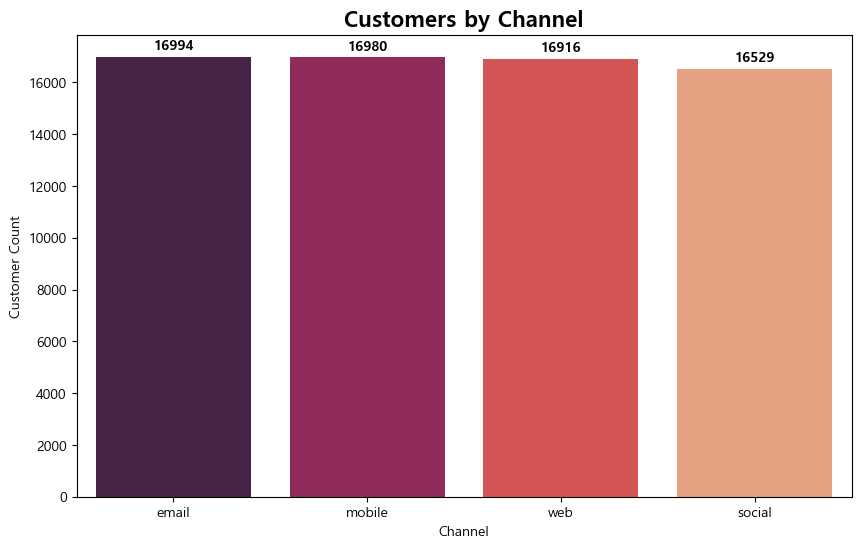

In [25]:
channels = ['web', 'email', 'mobile', 'social']

channel_customer_counts = {}
for ch in channels:
    unique_cnt = merge_df[merge_df[ch] == 1]['person'].nunique()
    channel_customer_counts[ch] = unique_cnt


channel_df = pd.DataFrame(list(channel_customer_counts.items()), columns=['Channel', 'Unique_Customers'])
channel_df = channel_df.sort_values(ascending=False,by='Unique_Customers')

print("채널별 고유 고객 수")
print(channel_df)



plt.figure(figsize=(10, 6))
ax = sns.barplot(data=channel_df, x='Channel', y='Unique_Customers', palette='rocket', hue='Channel', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontweight='bold')

plt.title('Customers by Channel', fontsize=16, fontweight='bold')
plt.ylabel('Customer Count')
plt.show()

비슷비슷해서 눈에 잘 띄지않음 -> 라인으로 강조

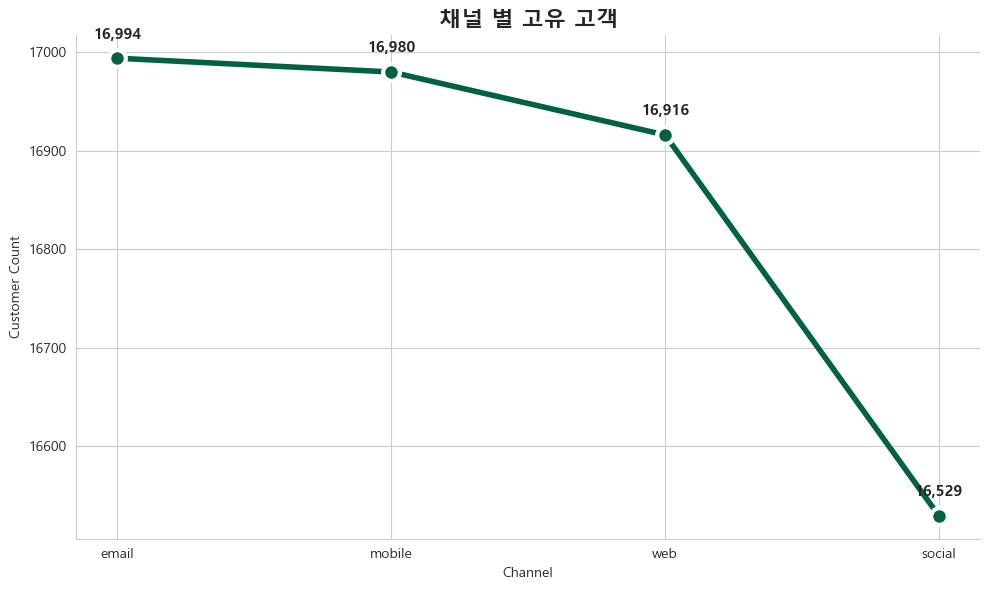

In [96]:
plt.figure(figsize=(10, 6))

ax = sns.lineplot(data=channel_df, x='Channel', y='Unique_Customers', 
                marker='o', markersize=12, linewidth=4, 
                color=SB_GREEN,  # 선 색상
                markeredgewidth=3)

for i, val in enumerate(channel_df['Unique_Customers']):
    plt.text(i, val + 20, f'{val:,}', ha='center', fontweight='bold', fontsize=11)

plt.title('채널 별 고유 고객', fontsize=16, fontweight='bold')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

## 7. 채널별 고객 수

쿠폰을 본 사람들의 리스트 만들기

merge -> is_viewed가 True면 오퍼에 반응 후 완료, False면 우연히 완료

informational은 completed가 될 수 없음 -> 제외



쿠폰 보고 완료: 28,382 건
쿠폰 안 보고 완료: 4,800 건


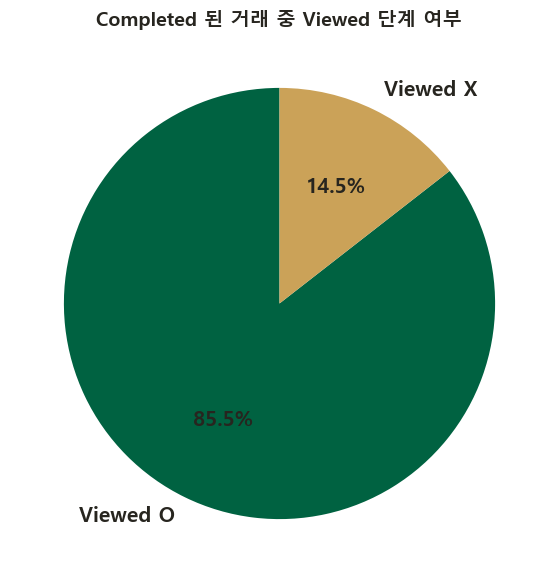

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

completed_data = merge_df[merge_df['event'] == 'completed']
viewed_data = merge_df[merge_df['event'] == 'viewed']

viewed_users = viewed_data[['person', 'offer_id']].drop_duplicates()
viewed_users['is_viewed'] = True 

check_df = pd.merge(completed_data, viewed_users, on=['person', 'offer_id'], how='left')

check_df['is_viewed'] = check_df['is_viewed'].fillna(False)

true_roi = len(check_df[check_df['is_viewed'] == True])
accidental_roi = len(check_df[check_df['is_viewed'] == False])

print(f"쿠폰 보고 완료: {true_roi:,} 건")
print(f"쿠폰 안 보고 완료: {accidental_roi:,} 건")


labels = ['Viewed O', 'Viewed X']
sizes = [true_roi, accidental_roi]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=[SB_GREEN, SB_GOLD],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 15, 'fontweight': 'bold'})


plt.title('Completed 된 거래 중 Viewed 단계 여부', fontsize=14, fontweight='bold')
plt.show()

## 8. 오퍼 종류 별 고객이 Completed까지 걸리는 time 평균

Completed까지 완료한 로그 중 오퍼별로 그룹 -> 평균

informational은 completed가 X -> 제거

In [28]:
merge_df[(merge_df['offer_label']=='informational_1')&(merge_df['event']=='completed')]

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label


In [29]:
completed_df = noinfo_merge_df[noinfo_merge_df['event'] == 'completed']
completed_df.tail(2)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label
306112,8431c16f8e1d440880db371a68f82dd0,completed,714,fafdcd668e3743c1bb461111dcafc2a4,NaN,2.0,30,M,39.0,8431c16f8e1d440880db371a68f82dd0,2018-06-27,39000.0,0,0,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3
306130,24f56b5e1849462093931b164eb803b5,completed,714,fafdcd668e3743c1bb461111dcafc2a4,NaN,2.0,30,F,48.0,24f56b5e1849462093931b164eb803b5,2017-12-28,80000.0,0,0,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3


In [30]:
completed_df = noinfo_merge_df[noinfo_merge_df['event'] == 'completed']

avg_completion_time = completed_df.groupby('offer_label')['time'].mean().sort_values()

print("오퍼별 평균 완료 시점")
print(avg_completion_time)

오퍼별 평균 완료 시점
offer_label
bogo_4        381.819334
bogo_2        384.539836
bogo_1        393.053645
discount_3    397.862108
discount_2    399.349765
bogo_3        405.696491
discount_4    408.381433
discount_1    429.556886
Name: time, dtype: float64


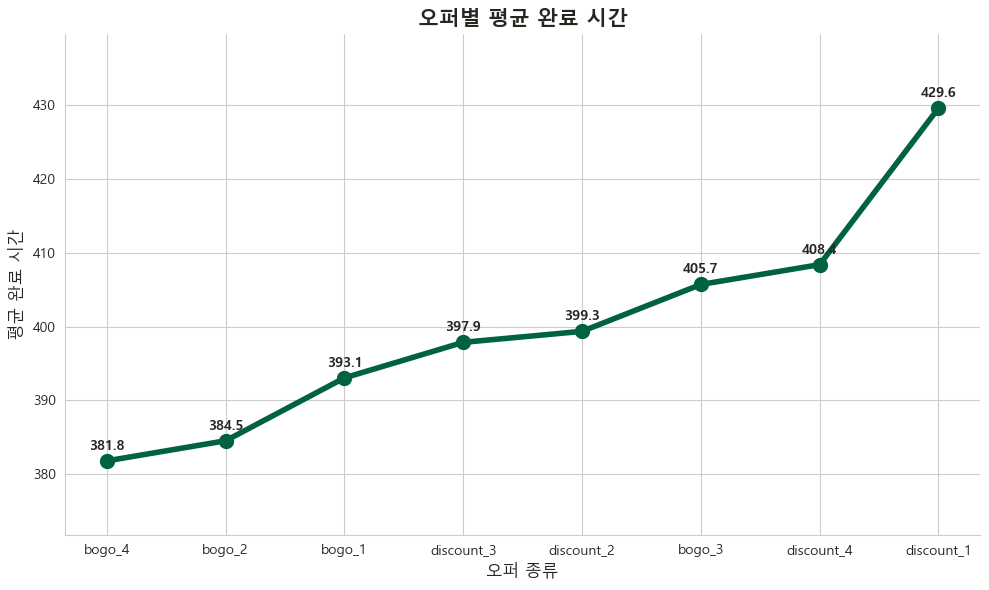

In [107]:
plt.figure(figsize=(10, 6))

plt.plot(avg_completion_time.index, avg_completion_time.values, 
         marker='o', linestyle='-', linewidth=4, markersize=8, 
         color=SB_GREEN,        
         markeredgewidth=3)

y_min = avg_completion_time.min() - 10
y_max = avg_completion_time.max() + 10
plt.ylim(y_min, y_max)

for i, v in enumerate(avg_completion_time.values):
    plt.text(i, v + 1.5, f"{v:.1f}", ha='center', fontsize=10, fontweight='bold')

plt.title('오퍼별 평균 완료 시간', fontsize=15, fontweight='bold')
plt.xlabel('오퍼 종류', fontsize=12)
plt.ylabel('평균 완료 시간', fontsize=12)

plt.tight_layout()
plt.show()

# 대시보드 2 : 오퍼/채널별 성과 요약

##### 1. [오퍼별]
1-1. 총 발송 수

1-2. 총 열람 수

1-3. 총 완료 수

1-4. 전체 완료율

1-5. 총 오퍼 연계 매출

1-6. 발송 1건당 평균 매출

1-7. 완료 1건당 평균 매출

1-8. 평균 객단가

##### 2. [채널별]
2-1. 총 채널별 발송 수 - 필터

2-2. 채널별 열람률 - 필터

2-3. 채널별 완료율 - 필터

2-4. 채널별 총 매출 - 필터

2-5. 채널별 평균 매출

2-6. 채널별 객단가

2-7. 채널별 거래 횟수

2-8. 채널별 발송 1건당 매출

##### 3. [오퍼-채널]
행: 채널

열: 오퍼

값: 완료율이나 매출(평균 or 총)

##### 4. [오퍼 효율 분석]

X축: 완료율

Y축: 발송 1건당 매출

점 크기: 총매출

색상: 오퍼 유형

## 1. 오퍼별

## 1-1. 총 발송 수

In [32]:
total_received = len(merge_df[merge_df['event'] == 'received'])

print(f"총 발송 수 : {total_received:,} 건")

총 발송 수 : 76,277 건


## 1-2. 총 열람 수

In [33]:
total_viewed = len(merge_df[merge_df['event'] == 'viewed'])

print(f"총 열람 수 : {total_viewed:,} 건")

총 열람 수 : 57,725 건


## 1-3. 총 완료 수

In [34]:
total_completed = len(merge_df[merge_df['event'] == 'completed'])

print(f"총 완료 수 : {total_completed:,}")

총 완료 수 : 33,182


## 1-4. 전체 완료율

In [35]:
total_completion_rate = (total_completed / total_received) * 100

print(f"전체 오퍼 완료율: {total_completion_rate:.2f}%")

전체 오퍼 완료율: 43.50%


10명에게 쿠폰을 보냈을 때 4명 이상이 실제로 미션을 끝냈다는 뜻

amount에서 reward를 뺸 게 순수익?? -> 위험, 순화 표현 필요

## <<오퍼 효율 분석>>

x축 : 완료율

y축 : 발송 1건당 매출

점크기 : 총 매출 

색상 : 오퍼 유형

informatinal 제외

##### x축 : 완료율 (viewed -> completed)

In [81]:
df_core = merge_df[merge_df['offer_label'].notna()].copy()
df_core = df_core[~df_core['offer_label'].str.contains('informational')]

print(df_core['offer_label'].value_counts())

received_cnt = df_core[df_core['event'] == 'received'].groupby('offer_label')['person'].count()
viewed_cnt = df_core[df_core['event'] == 'viewed'].groupby('offer_label')['person'].count()

# 같은 사람이 같은 오퍼를 여러번 본 경우 처음 봤을 때만 남김
viewed_events = df_core[df_core['event'] == 'viewed'][['person', 'offer_label', 'time']].rename(columns={'time': 'viewed_time'})
viewed_events = viewed_events.groupby(['person', 'offer_label'])['viewed_time'].min().reset_index()


completed_events = df_core[df_core['event'] == 'completed'][['person', 'offer_label', 'time']].rename(columns={'time': 'completed_time'})

# 같은 사람과 같은 오퍼를 기준으로 viewed와 completed 연결
true_comp_df = pd.merge(completed_events, viewed_events, on=['person', 'offer_label'], how='left')
true_comp_df = true_comp_df[
    (true_comp_df['viewed_time'].notna()) &
    (true_comp_df['viewed_time'] <= true_comp_df['completed_time'])
]

true_completed_cnt = true_comp_df.groupby('offer_label')['person'].count()

print("\n Viewed -> Completed 만족",true_completed_cnt)

offer_label
discount_3    20189
discount_2    20095
bogo_4        19097
bogo_2        18192
bogo_1        18009
bogo_3        16151
discount_4    15714
discount_1    13671
Name: count, dtype: int64

 Viewed -> Completed 만족 offer_label
bogo_1        2758
bogo_2        2852
bogo_3        2333
bogo_4        3647
discount_1    1451
discount_2    4509
discount_3    4766
discount_4    2298
Name: person, dtype: int64


##### y축 : 발송 1건당 매출 

In [82]:
transactions = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]

true_completions_for_rev = true_comp_df[['person', 'completed_time', 'offer_label']].rename(columns={'completed_time': 'time'})

# 오퍼 완료한 순간의 거래만 가져옴 (해찬님 코드 참고)
matched_sales = pd.merge(transactions, true_completions_for_rev, on=['person', 'time'], how='inner')

# 오퍼별 총 매출 집계
revenue_df = matched_sales.groupby('offer_label').agg(
    total_offer_revenue=('amount', 'sum')
)

revenue_df

,total_offer_revenue
offer_label,
bogo_1,65084.60
bogo_2,68123.31
bogo_3,42701.11
bogo_4,73038.10
discount_1,37830.57
discount_2,77078.86
discount_3,85729.59
discount_4,46485.54


#####  KPI 통합 

In [72]:
final_kpi_df = pd.DataFrame({
    'received_cnt': received_cnt,
    'viewed_cnt': viewed_cnt,
    'true_completed_cnt': true_completed_cnt
}).fillna(0).join(revenue_df).fillna(0)

final_kpi_df

,received_cnt,viewed_cnt,true_completed_cnt,total_offer_revenue
offer_label,,,,
bogo_1,7658,6716,2758,65084.60
bogo_2,7593,7298,2852,68123.31
bogo_3,7677,4171,2333,42701.11
bogo_4,7571,7264,3647,73038.10
discount_1,7668,2663,1451,37830.57
discount_2,7646,7337,4509,77078.86
discount_3,7597,7327,4766,85729.59
discount_4,7632,4118,2298,46485.54


##### X축 : 실제 완료율 = 실제 완료 수 / 총 발송 수 (여기서 실제란 Viewed -> Completed 과정을 거침)

#####  Y축 : 발송 1건당 매출 = 총 오퍼 연계 매출 / 총 발송 수

In [73]:
final_kpi_df['true_completed_rate'] = (final_kpi_df['true_completed_cnt'] / final_kpi_df['received_cnt'] * 100).round(2)

final_kpi_df['revenue_per_send'] = (final_kpi_df['total_offer_revenue'] / final_kpi_df['received_cnt']).round(2)

색상 구분 위해서 BOGO, Discount 그룹 묶고 컬럼 추가

In [74]:
final_kpi_df = final_kpi_df.reset_index()
final_kpi_df['offer_type'] = final_kpi_df['offer_label'].apply(lambda x: 'bogo' if 'bogo' in x else 'discount')

분모에 0들어가면 에러 위험 -> nan으로 채움

In [75]:
final_kpi_df['received_cnt'] = final_kpi_df['received_cnt'].replace(0, np.nan)

##### 산점도 그리기

| 요소 | 의미                   |
| -- | -------------------- |
| X축 | 완료율 (얼마나 잘 전환되었는지)     |
| Y축 | 발송당 매출 (얼마나 돈 잘 벌었는지) |
| 크기 | 총매출 (얼마나 크게 벌었는지)     |
| 색  | 오퍼 유형                |


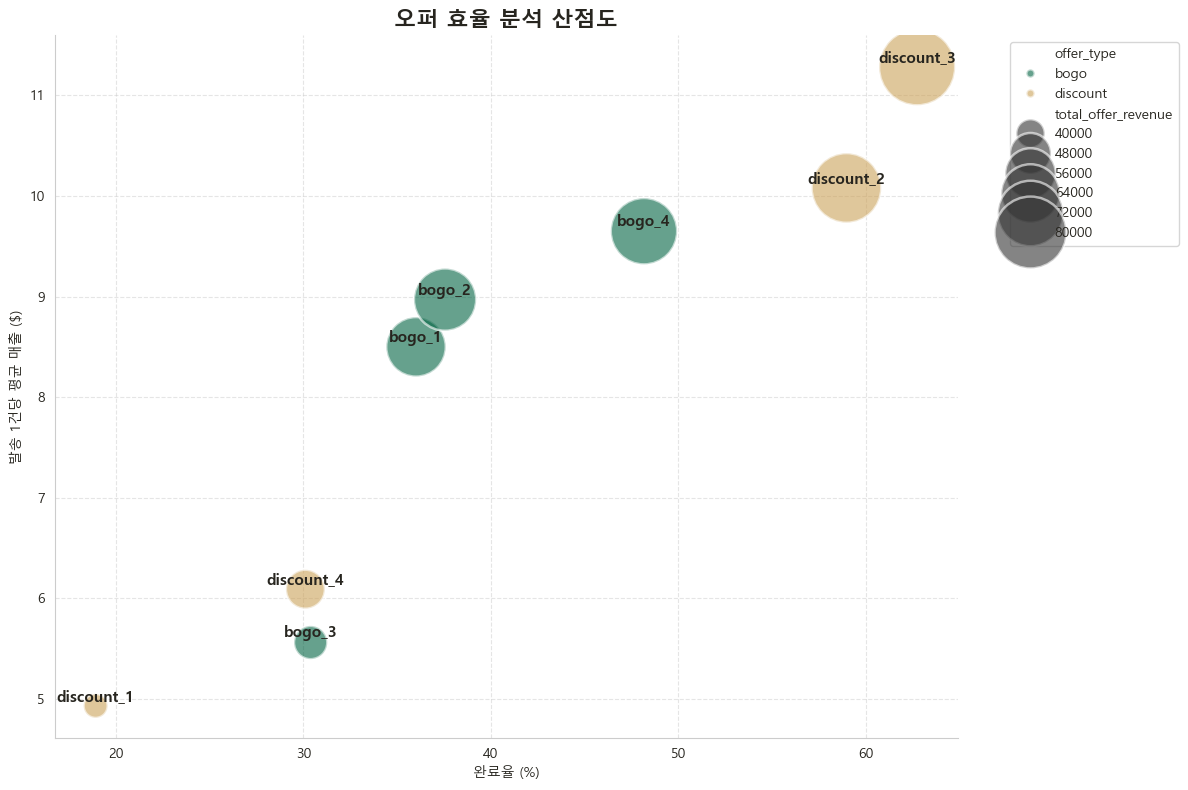

In [116]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=final_kpi_df,
    x='true_completed_rate', # 완료율
    y='revenue_per_send', # 발송 1건당 평균 매출
    size='total_offer_revenue', # 총 매출
    hue='offer_type',  # 색상 구분
    sizes=(300, 3000),
    alpha=0.6,
)

# 라벨 추가
for i in range(len(final_kpi_df)):
    plt.text(
        final_kpi_df['true_completed_rate'].iloc[i],
        final_kpi_df['revenue_per_send'].iloc[i] + 0.05,
        final_kpi_df['offer_label'].iloc[i],
        ha='center',
        fontsize=11,
        fontweight='bold',
        color=SB_BLACK
    )

plt.title('오퍼 효율 분석 산점도', fontsize=16, fontweight='bold')
plt.xlabel('완료율 (%)')
plt.ylabel('발송 1건당 평균 매출 ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 해석

오른쪽에 있을수록 고객들이 좋아하고 잘 참여하는 오퍼 (높은 완료율)

위에 있을수록 한 번 발송할 때마다 돈을 많이 벌어다 주는 오퍼 (높은 수익성)

점이 클수록 회사 전체 매출에 기여하는 바가 큰 오퍼 (큰 규모)

색깔은 이게 BOGO인지 Discount인지 구분 (오퍼 유형)

### 알 수 있는 것

1. discount_3과 discount_2의 높은 완료율과 높은 원의 크기 (총 매출)

-> 고객들이 쉽게 참여하면서도 돈을 많이 쓰게 하는 최고의 오퍼

2. 중앙에 모여있는 bogo_1, bogo_2, bogo_4

-> 최고 1등은 아니지만 안정적인 성과를 보여줌

3. 하단에 있는 오퍼들 discount_1, discount_4, bogo_3

-> 완료율도 30% 이하이며 건당 매출도 5~6$로 낮음, 조건이 까다롭거나 보상이 별로?

4. 할인 쿠폰은 조건을 어떻게 짜느냐에 따라 큰 차이가 남

## <<오퍼별 고객 평균 매출 (고객당 객단가)>>

오퍼라벨 찍어서 라벨이 없는 거래 건은 일반으로 분리

일반과 오퍼건을 합쳐서 그래프 그리기

In [153]:
matched_sales.head()

,person,time,amount,offer_label
0,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,0,34.56,discount_4
1,629fc02d56414d91bca360decdfa9288,0,33.90,bogo_3
2,676506bad68e4161b9bbaffeb039626b,0,18.01,bogo_1
3,8f7dd3b2afe14c078eb4f6e6fe4ba97d,0,19.11,bogo_2
4,227f2d69e46a4899b70d48182822cff6,0,28.39,bogo_2


In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#뻥튀기방지
clean_matched = matched_sales.drop_duplicates(subset=['person', 'time'], keep='first')

all_sales = pd.merge(
    transactions, 
    clean_matched[['person', 'time', 'offer_label']], 
    on=['person', 'time'], 
    how='left'
)

# 오퍼 안쓰면 일반
all_sales['offer_label'] = all_sales['offer_label'].fillna('Regular (일반 결제)')

# informational 제외
final_data = all_sales[~all_sales['offer_label'].str.contains('informational', na=False)].copy()



summary_df = final_data.groupby('offer_label').agg(
    총_매출=('amount', 'sum'),
    결제유저수=('person', 'nunique'),  # 중복 없는 순수 유저 수 
    결제건수=('amount', 'count')     # 전체 결제 횟수 
).reset_index()

# 계산

# ARPU = 1인당 평균 결제 금액
summary_df['ARPU($)'] = (summary_df['총_매출'] / summary_df['결제유저수']).round(2)

# AOV = 1회 결제당 평균 금액 (객단가)
summary_df['AOV_객단가($)'] = (summary_df['총_매출'] / summary_df['결제건수']).round(2)

# 1인이 해당 오퍼/일반결제로 평균 몇 번 결제했는지 확인
summary_df['인당_평균결제횟수'] = (summary_df['결제건수'] / summary_df['결제유저수']).round(2)

# 오퍼 종류별 구분을 위한 타입 지정 함수
def assign_type(label):
    if 'bogo' in label: return 'BOGO'
    elif 'discount' in label: return 'Discount'
    else: return 'Regular'

summary_df['Type'] = summary_df['offer_label'].apply(assign_type)

final_result = summary_df.sort_values(by='ARPU($)', ascending=False)
display(final_result[['offer_label', 'Type', 'AOV_객단가($)', 'ARPU($)', '인당_평균결제횟수']])

,offer_label,Type,AOV_객단가($),ARPU($),인당_평균결제횟수
0,Regular (일반 결제),Regular,11.33,80.07,7.07
5,discount_1,Discount,26.07,29.97,1.15
2,bogo_2,BOGO,23.98,27.49,1.15
1,bogo_1,BOGO,23.40,26.86,1.15
8,discount_4,Discount,19.54,22.36,1.14
4,bogo_4,BOGO,19.56,22.08,1.13
7,discount_3,Discount,17.80,20.62,1.16
3,bogo_3,BOGO,18.07,20.60,1.14
6,discount_2,Discount,16.73,19.28,1.15


### AOV 객단가

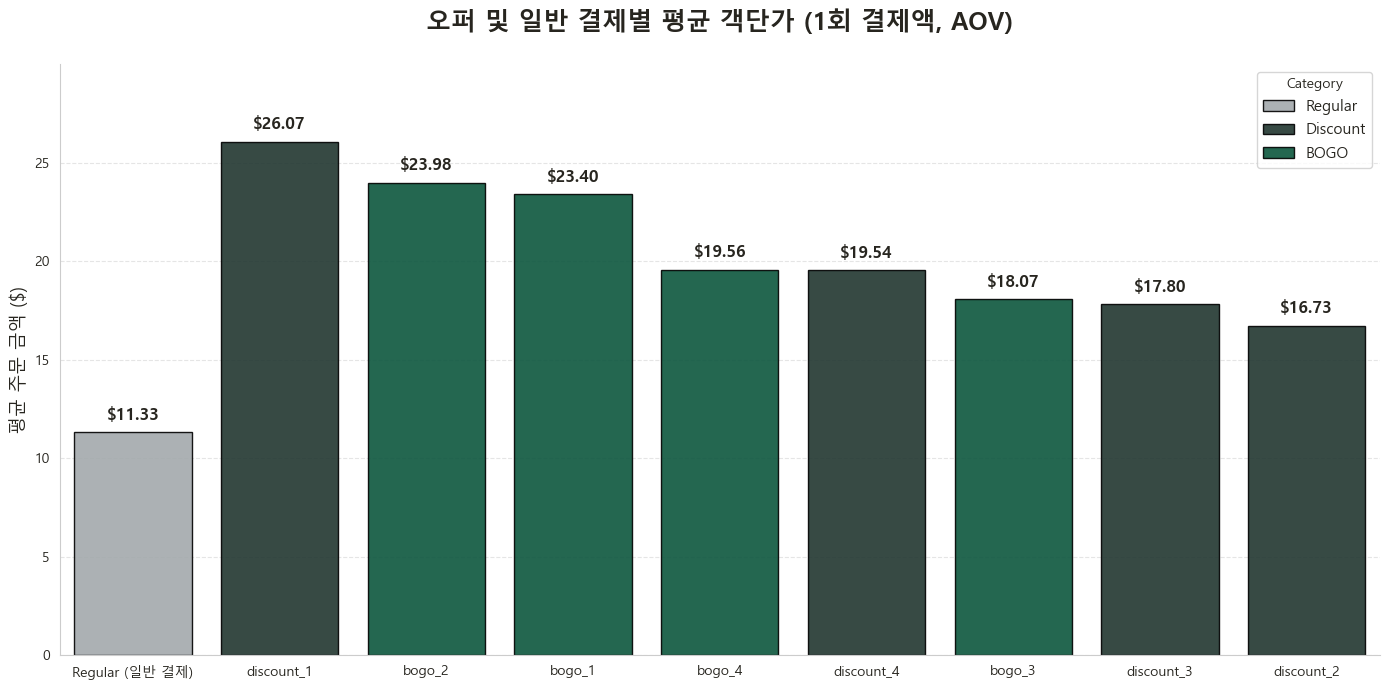

In [156]:
plot_df = summary_df.copy()
plot_df['sort_order'] = plot_df['Type'].apply(lambda x: 0 if x == 'Regular' else 1)
plot_df = plot_df.sort_values(by=['sort_order', 'AOV_객단가($)'], ascending=[True, False]).drop(columns='sort_order')

custom_palette = {'BOGO': SB_GREEN, 'Discount': SB_DEEP_GREEN, 'Regular': SB_GREY}

plt.figure(figsize=(14, 7))

ax1 = sns.barplot(
    data=plot_df, x='offer_label', y='AOV_객단가($)', hue='Type', 
    palette=custom_palette, dodge=False, edgecolor='black', alpha=0.9
)

plt.title('오퍼 및 일반 결제별 평균 객단가 (1회 결제액, AOV)', fontsize=18, fontweight='bold', pad=25)
plt.ylabel('평균 주문 금액 ($)', fontsize=13)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax1.patches:
    val = p.get_height()
    if val > 0:
        ax1.annotate(f'${val:.2f}', (p.get_x() + p.get_width() / 2., val),
                    ha='center', va='bottom', fontsize=12, fontweight='bold', 
                    xytext=(0, 6), textcoords='offset points')

plt.ylim(0, plot_df['AOV_객단가($)'].max() * 1.15)
plt.legend(title='Category', loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

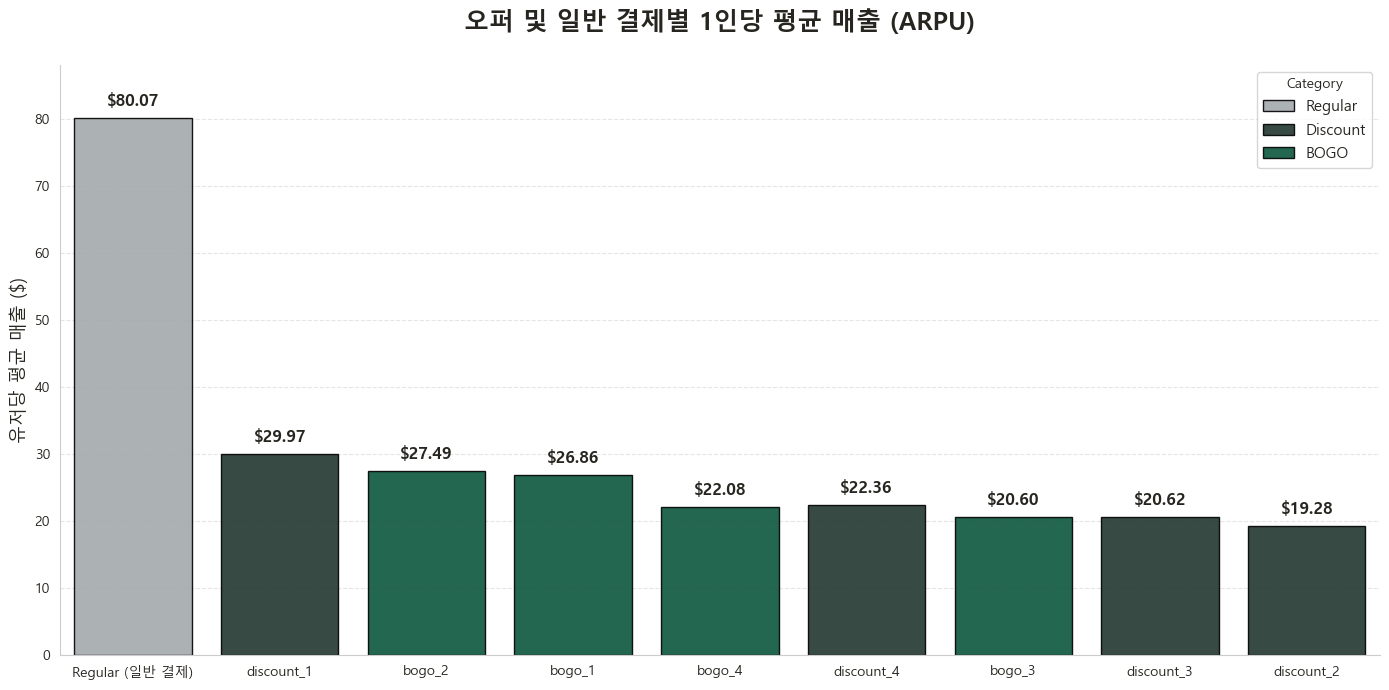

In [157]:
plt.figure(figsize=(14, 7))

ax2 = sns.barplot(
    data=plot_df, x='offer_label', y='ARPU($)', hue='Type', 
    palette=custom_palette, dodge=False, edgecolor='black', alpha=0.9
)

plt.title('오퍼 및 일반 결제별 1인당 평균 매출 (ARPU)', fontsize=18, fontweight='bold', pad=25)
plt.ylabel('유저당 평균 매출 ($)', fontsize=13)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax2.patches:
    val = p.get_height()
    if val > 0:
        ax2.annotate(f'${val:.2f}', (p.get_x() + p.get_width() / 2., val),
                    ha='center', va='bottom', fontsize=12, fontweight='bold', 
                    xytext=(0, 6), textcoords='offset points')

plt.ylim(0, plot_df['ARPU($)'].max() * 1.1)
plt.legend(title='Category', loc='upper right', fontsize=11) 
plt.tight_layout()
plt.show()

### 코드 설명

transactions(모든 결제 목록)과 cleaned_matched(오퍼 성공 기록)을 merge할 때 on = ['person','time'] 로 사용함 (결제 시간과 오퍼 완료 시간이 일치하는 경우 레이블이 붙음)

(위랑 같은 말) 고객이 offer completed 이벤트를 발생시킨 time에 발생한 transaction 데이터를 골라내서 offer_label 부여

informational은 제외

결과 -> 특정 오퍼의 유효 기간 내에 있더라도 오퍼 완료 조건이 충족되지 않은 일반 결제는 left join 시 nan으로 남아 일반 결제로 분류

머지 과정 (내 코드 상) : matched_sales는 이전에 사용했던 코드 : transaction (전체 거래) 와 viewed-> completed 된 기록을 inner join

matched_sales과 transation은 left join해서 일반 거래 찾기


그 이후에는 오퍼 종류 별로 총 매출, 결제 유저 수, 결제 건 수를 계산한뒤 ARPU와 AOV 계산
